# Pre-Installation

In [ ]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.8 MB/s eta 0:00:00


In [ ]:
pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=375c65c8def384e170c908bbb9b8807abd215c6e911ad187a61ed2115d464cad
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 111.7 MB/s eta 0:00:00


# Bell State Circuit

## Create a circuit

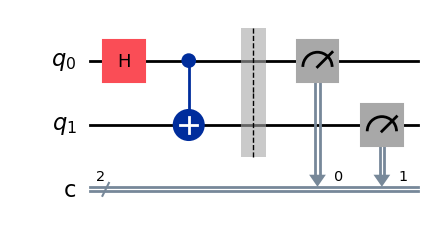

In [ ]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

# --- 1) Build a Bell-state circuit (|Φ+> = (|00> + |11>)/√2) ---
qc = QuantumCircuit(2, 2)
qc.h(0)          # Put qubit 0 in superposition
qc.cx(0, 1)      # Entangle: control q0 -> target q1
qc.barrier()
qc.measure([0, 1], [0, 1])

# Draw the circuit
display(qc.draw('mpl'))

## Execute with Aer Simulator

Measurement counts: {'11': 502, '00': 522}


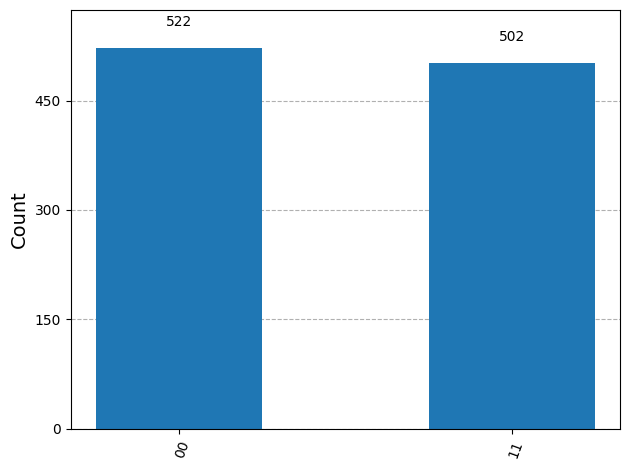

In [ ]:
# --- 2) Transpile for AerSimulator and run shot-based simulation ---
backend = AerSimulator()
tqc = transpile(qc, backend)   # <- required step to match backend
job = backend.run(tqc, shots=1024)
result = job.result()
counts = result.get_counts()

# Display the measurement counts result
print("Measurement counts:", counts)

# Plot the histogram the circuit result
plot_histogram(counts)

## Execute with QASM Simulator

In [ ]:
from qiskit_aer import Aer

Measurement counts: {'11': 503, '00': 521}


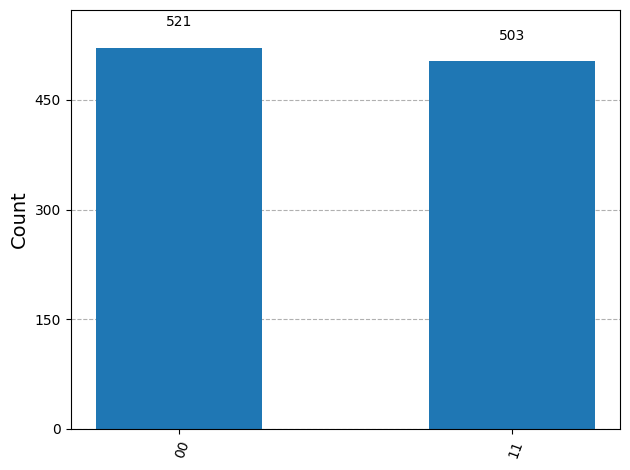

In [ ]:
# --- 2) Use qasm_simulator (shots-based) ---
backend = Aer.get_backend("qasm_simulator")
tqc = transpile(qc, backend)
job = backend.run(tqc, shots=1024, seed_simulator=42)
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)
plot_histogram(counts)

## Execute with Statevector Simulator

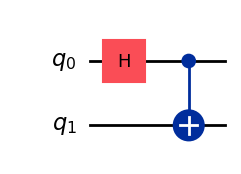

In [ ]:
# --- 1) Bell state circuit (NO measurement for statevector) ---
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Draw the circuit
display(qc.draw("mpl"))

In [ ]:
# --- 2) Run on StatevectorSimulator ---
backend = Aer.get_backend("statevector_simulator")
tqc = transpile(qc, backend)
job = backend.run(tqc)
result = job.result()

# Get statevector
sv = result.get_statevector(tqc)
print("Statevector:", sv)  # Expect ~[1/√2, 0, 0, 1/√2] for |00> and |11>

Statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


## Execute with Unitary Simulator

In [ ]:
import numpy as np

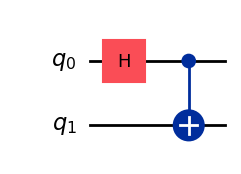

In [ ]:
# Build the Bell-state *unitary* (no measure, no classical bits)
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

display(qc.draw("mpl"))

In [ ]:
# Use the unitary simulator
backend = Aer.get_backend("unitary_simulator")
tqc = transpile(qc, backend)
result = backend.run(tqc).result()

U = result.get_unitary(tqc)      # 4x4 unitary as a NumPy array
print("Unitary matrix:\n", np.array(U))

Unitary matrix:
 [[ 0.70710678+0.00000000e+00j  0.70710678-8.65956056e-17j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.70710678+0.00000000e+00j -0.70710678+8.65956056e-17j]
 [ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.70710678+0.00000000e+00j  0.70710678-8.65956056e-17j]
 [ 0.70710678+0.00000000e+00j -0.70710678+8.65956056e-17j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j]]


## Aer Simulator Methods and Devices

In [ ]:
# Check the available methods and devices in AerSimulator
backend = AerSimulator()
print("AerSimulator methods:", backend.available_methods())
print("AerSimulator devices:", backend.available_devices())  # e.g., CPU, GPU

AerSimulator methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
AerSimulator devices: ('CPU',)


## Execute with Fake Device

In [ ]:
pip install -U qiskit_ibm_runtime

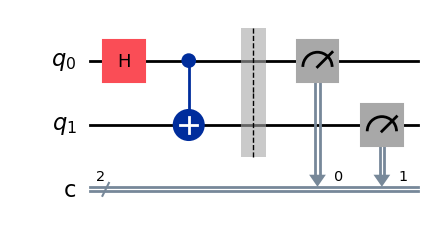

In [ ]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakePerth
# FakeJakarta, FakeToronto

fake_backend = FakePerth()

# --- Build your Bell circuit (keep measurements for counts) ---
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.barrier()
qc.measure([0, 1], [0, 1])

display(qc.draw("mpl"))

Measurement counts (noisy, fake device): {'01': 37, '10': 27, '00': 450, '11': 510}


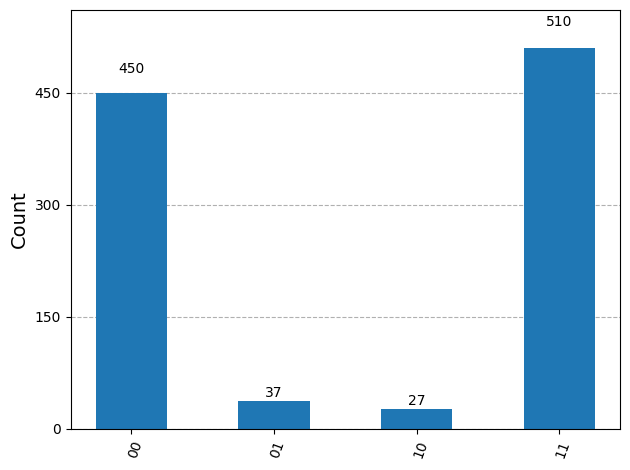

In [ ]:
# --- Create a noisy Aer simulator that mimics the fake device ---
# This includes basis_gates, coupling_map, and calibrated noise.
noisy_sim = AerSimulator.from_backend(fake_backend)

# (Alternative manual construction)
# noise_model = NoiseModel.from_backend(fake_backend)
# noisy_sim = AerSimulator(noise_model=noise_model,
#                          basis_gates=noise_model.basis_gates,
#                          coupling_map=fake_backend.configuration().coupling_map)

# --- Transpile *for the fake device* (so mapping & basis match)
tqc = transpile(qc, backend=fake_backend, optimization_level=1, seed_transpiler=42)

# --- Run on the noisy simulator ---
job = noisy_sim.run(tqc, shots=1024, seed_simulator=123)
result = job.result()
counts = result.get_counts()

print("Measurement counts (noisy, fake device):", counts)
plot_histogram(counts)
# plt.show()

## Execute on Real Device

In [ ]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
# from qiskit.providers.ibmq import IBMQ  ## Superseded
# from qiskit-ibm-provider import IBMQ    ## Outdated
from qiskit_ibm_runtime import QiskitRuntimeService

# --- 0) Login to IBMQ (use load_account() if you've saved it before) ---
# IBMQ.save_account("YOUR_IBM_Q_API_TOKEN", overwrite=True)  # run once, then comment out
# IBMQ.enable_account("YOUR_IBM_Q_API_TOKEN")  # or: IBMQ.load_account()

service = QiskitRuntimeService()
service.enable_account("YOUR_IBM_Q_API_TOKEN")

# Adjust hub/group/project to match your account if needed
# provider = IBMQ.get_provider(hub="ibm-q")
provider = service.get_provider(hub="ibm-q")

# --- 1) Pick the specific real backend (Toronto) ---
backend = provider.get_backend("ibmq_toronto")
print("Using real device:", backend.name())

In [ ]:
# --- 2) Build the Bell-state circuit (|Φ+> = (|00> + |11>)/√2) ---
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.barrier()
qc.measure([0, 1], [0, 1])

# Draw the circuit (Jupyter)
display(qc.draw("mpl"))

In [ ]:
# --- 3) Transpile for the real device (maps to its basis/coupling) ---
tqc = transpile(qc, backend=backend, optimization_level=1, seed_transpiler=42)

# --- 4) Run on hardware ---
# You can lower shots to reduce queue time while testing
job = backend.run(tqc, shots=2048)
print("Submitted job ID:", job.job_id())

# Wait for completion and fetch results
result = job.result()
counts = result.get_counts()
print("Hardware counts:", counts)

# --- 5) Visualize ---
plot_histogram(counts)
plt.show()

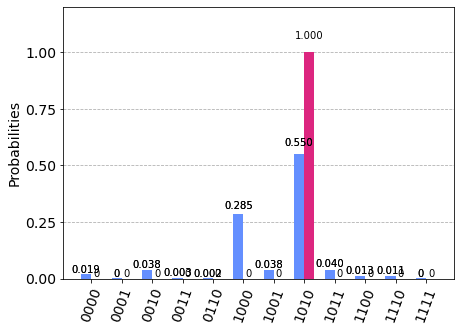

# Quantum Phase Kickback

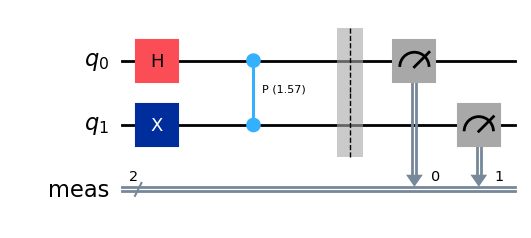

In [ ]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

# Step 1: Create 2-qubit circuit
qc = QuantumCircuit(2)

# Step 2: Put control qubit in superposition
qc.h(0)

# Step 3: Prepare target in eigenstate of U (|1> works for Phase gate)
qc.x(1)

# Step 4: Apply controlled-phase rotation (U = Phase(θ))
theta = 1.5708  # π/2
qc.cp(theta, 0, 1)

# Step 5: Measure both qubits
qc.measure_all()

# Step 6: Run simulation
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

# Step 7: Get counts and plot
counts = result.get_counts()
plot_histogram(counts)
plt.show()

# Optional: View the circuit
qc.draw('mpl')

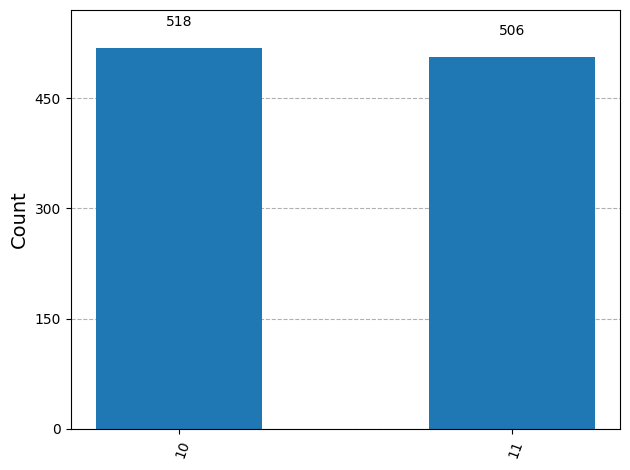

In [ ]:
# Step 6: Run simulation
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

# Step 7: Get counts and plot
counts = result.get_counts()
plot_histogram(counts)
# plt.show()

# Optional: View the circuit
# qc.draw('mpl')

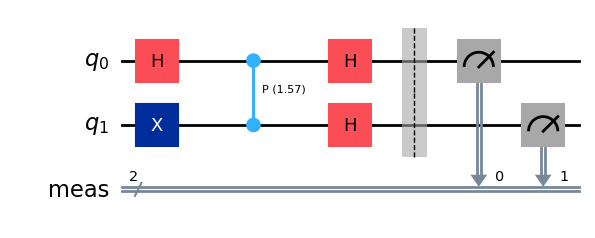

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

# Step 1: Create a 2-qubit circuit
qc = QuantumCircuit(2)

# Step 2: Put the control qubit (q0) in superposition
qc.h(0)

# Step 3: Prepare the target qubit (q1) in an eigenstate of U
# For the Phase gate, |1> is an eigenstate.
qc.x(1)

# Step 4: Apply controlled-phase rotation (U = Phase(θ))
theta = 1.5708  # π/2
qc.cp(theta, 0, 1)

# Step 5: Apply Hadamard to control to convert phase into measurable probability
qc.h(0)

# (Optional) Apply H to target if you want to bring it back to computational basis
# Not required for the phase kickback demonstration itself
qc.h(1)

# Step 6: Measure both qubits
qc.measure_all()

# Step 8: View Bloch sphere of state before measurement
qc_no_measure = QuantumCircuit(2)
qc_no_measure.h(0)
qc_no_measure.x(1)
qc_no_measure.cp(theta, 0, 1)
state = Statevector.from_instruction(qc_no_measure)
plot_bloch_multivector(state)

# Optional: Draw circuit
qc.draw('mpl')

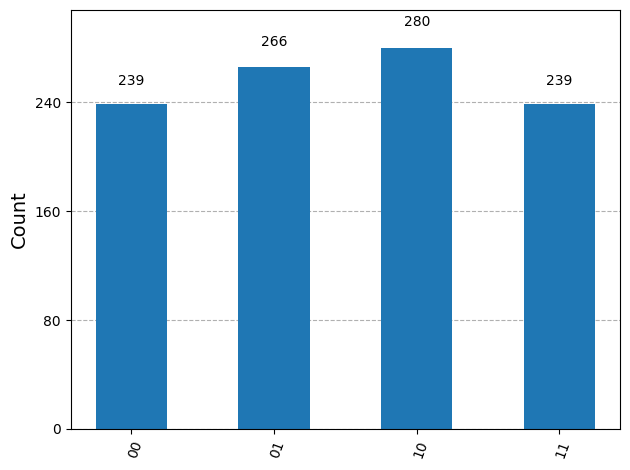

In [ ]:
# --- Simulation ---
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

# Step 7: Get probabilities and visualize
counts = result.get_counts()
plot_histogram(counts)
# plt.show()


# Deutsch–Jozsa Algorithm

In [ ]:
import qiskit
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import pylatexenc
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
# from qiskit.providers.aer import AerSimulator

In [ ]:
# Function to automatically instantiate the oracle circuit
def balancedOracle(circuit):
    circuit.barrier()
    circuit.x([0,2])
    circuit.cx([0,2] , 3)
    circuit.x([0,2])
    circuit.barrier()
    return circuit

## Classical Circuit

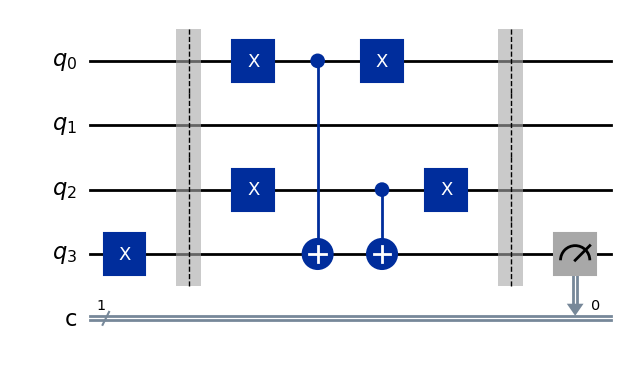

In [ ]:
# number of qubits
n = 3

# initialize circuit
classicalCircuit = QuantumCircuit(n+1,1)

# add not gate to output bit
classicalCircuit.x(n)
# add the oracle to the circuit
classicalCircuit = balancedOracle(classicalCircuit)
# measure the output bit after the oracle
classicalCircuit.measure(n, 0)

display(classicalCircuit.draw('mpl'))

{'1': 1024}


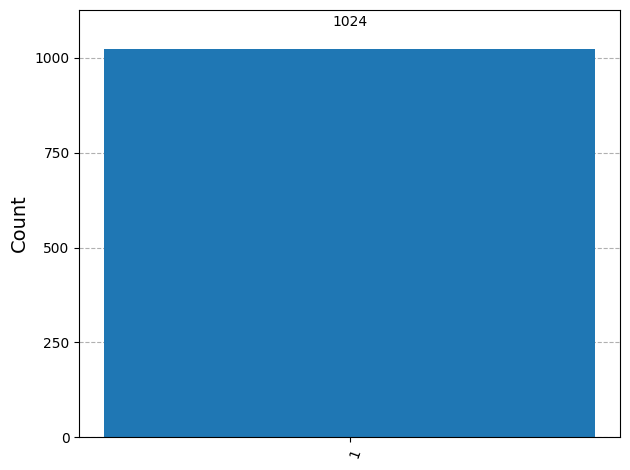

In [ ]:
# simulate outputs
sim = AerSimulator()
compiled = transpile(classicalCircuit, sim)
job = transpile(compiled)

result = sim.run(compiled).result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

## Quantum Circuit

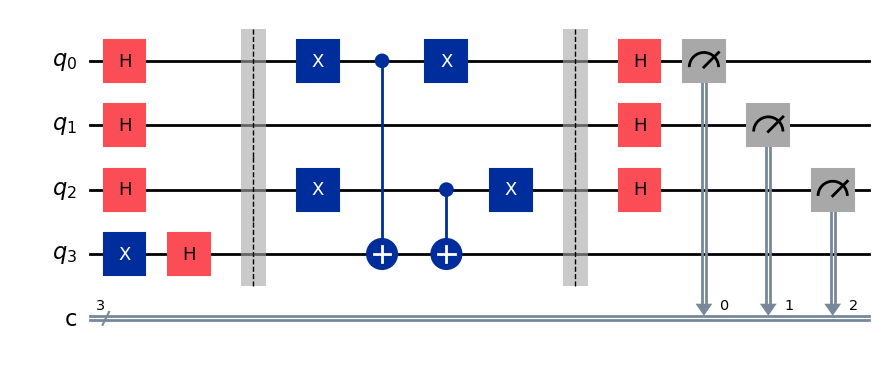

In [ ]:
# initialize circuit
dj_Circuit = QuantumCircuit(n+1, n)

# add not gate to the output qubit
dj_Circuit.x(n)
# add hadamard gates to all qubits
dj_Circuit.h(range(n+1))
# add the oracle to the circuit
dj_Circuit = balancedOracle(dj_Circuit)
# finish the "hadamard sandwich" by applying hadamards to the input qubits
dj_Circuit.h(range(n))
# measure the values of the input qubits
dj_Circuit.measure(range(n), range(n))

display(dj_Circuit.draw('mpl'))

{'101': 1024}


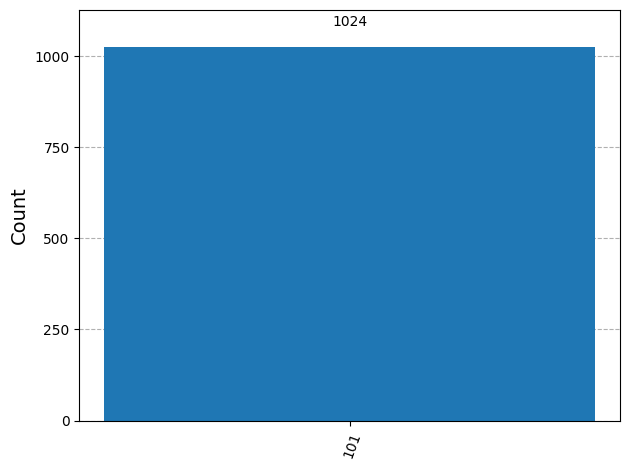

In [ ]:
# simulate outputs
sim = AerSimulator()
compiled = transpile(dj_Circuit, sim)
job = transpile(compiled)

result = sim.run(compiled).result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)